# Introduction to LCEL and LangGraph: LangChain Powered RAG

In the following notebook we're going to focus on learning how to navigate and build useful applications using LangChain, specifically LCEL, and how to integrate different APIs together into a coherent RAG application!

In the notebook, you'll complete the following Tasks:

- 🤝 Breakout Room #1:
  1. Install required libraries
  2. Set Environment Variables  
  3. Initialize a Simple Chain using LCEL
  4. Implement Naive RAG using LCEL
  5. Implement Simple RAG using LCEL

- 🤝 Breakout Room #2:
  1. Install LangGraph
  2. Understanding States and Nodes
  3. Building a Basic Graph
  4. Implementing a Simple RAG Graph
  5. Extending the Graph with Complex Flows

Let's get started!



# 🤝 Breakout Room #1

## Installing Required Libraries

One of the [key features](https://blog.langchain.dev/langchain-v02-leap-to-stability/) of LangChain v0.2.0 is the compartmentalization of the various LangChain ecosystem packages and added stability.

Instead of one all encompassing Python package - LangChain has a `core` package and a number of additional supplementary packages.

We'll start by grabbing all of our LangChain related packages!

> NOTE: DO NOT RUN THIS CELL IF YOU ARE RUNNING THIS NOTEBOOK LOCALLY

In [1]:
#!pip install -qU langchain==0.3.15 langchain-core==0.3.31 langchain-community==0.3.15 langchain-openai==0.3.1 langchain-qdrant==0.2.0 qdrant-client==1.13.2 tiktoken pymupdf==1.25.2

## Set Environment Variables

We'll be leveraging OpenAI's suite of APIs - so we'll set our `OPENAI_API_KEY` `env` variable here!

In [2]:
import os
import getpass

from dotenv import load_dotenv

load_dotenv()

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Initialize a Simple Chain using LCEL

The first thing we'll do is familiarize ourselves with LCEL and the specific ins and outs of how we can use it!

### LLM Orchestration Tool (LangChain)

Let's dive right into [LangChain](https://www.langchain.com/)!

The first thing we want to do is create an object that lets us access OpenAI's `gpt-4o` model.

In [9]:
from langchain_openai import ChatOpenAI
from openai import OpenAI

# Get list of available models
client = OpenAI()
models = client.models.list()
# Filter for text generation models (typically GPT models)
text_generation_models = [model for model in models.data if "gpt" in model.id.lower()]
models = text_generation_models
print("Available models:")
for model in models:
    print(f"- {model.id}")


Available models:
- gpt-4o-audio-preview-2024-12-17
- gpt-4o-audio-preview-2024-10-01
- gpt-4o-realtime-preview-2024-10-01
- gpt-4o-realtime-preview
- gpt-4
- gpt-4o-mini-audio-preview
- gpt-4-0125-preview
- gpt-4o-audio-preview
- gpt-4-turbo-preview
- gpt-4o-mini-realtime-preview
- gpt-4o-mini-realtime-preview-2024-12-17
- gpt-3.5-turbo-instruct-0914
- gpt-4o-mini-search-preview
- gpt-3.5-turbo-1106
- gpt-4-turbo
- gpt-4o-realtime-preview-2024-12-17
- gpt-3.5-turbo-instruct
- gpt-3.5-turbo
- chatgpt-4o-latest
- gpt-4o-mini-search-preview-2025-03-11
- gpt-4o-2024-11-20
- gpt-4o-2024-05-13
- gpt-3.5-turbo-16k
- gpt-4-turbo-2024-04-09
- gpt-4-1106-preview
- gpt-4-0613
- gpt-4o-search-preview
- gpt-4.5-preview
- gpt-4.5-preview-2025-02-27
- gpt-4o-search-preview-2025-03-11
- gpt-4o-mini-tts
- gpt-4o
- gpt-4o-mini
- gpt-4o-2024-08-06
- gpt-4o-transcribe
- gpt-4o-mini-2024-07-18
- gpt-4o-mini-transcribe
- gpt-4o-mini-audio-preview-2024-12-17
- gpt-3.5-turbo-0125


In [10]:
openai_chat_model = ChatOpenAI(model="gpt-4o-mini")


#### ❓ Question #1:

What other models could we use, and how would the above code change?

> HINT: Check out [this page](https://platform.openai.com/docs/models) to find the answer!

#### ❗ Answer #1:

> Used OpenAI API to list all existing models and filter for those that are 
> GPTs. See code above

### Prompt Template

Now, we'll set up a prompt template - more specifically a `ChatPromptTemplate`. This will let us build a prompt we can modify when we call our LLM!

In [11]:
from langchain_core.prompts import ChatPromptTemplate

system_template = """You are a legendary and mythical Wizard. 
You speak in riddles and make obscure and pun-filled references to exotic cheeses."""
human_template = "{content}"

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", system_template),
    ("human", human_template)
])

### Our First Chain

Now we can set up our first chain!

A chain is simply two components that feed directly into eachother in a sequential fashion!

You'll notice that we're using the pipe operator `|` to connect our `chat_prompt` to our `llm`.

This is a simplified method of creating chains and it leverages the LangChain Expression Language, or LCEL.

You can read more about it [here](https://python.langchain.com/v0.2/docs/concepts/#langchain-expression-language-lcel), but there a few features we should be aware of out of the box (taken directly from LangChain's documentation linked above):

- **Async, Batch, and Streaming Support** Any chain constructed this way will automatically have full sync, async, batch, and streaming support. This makes it easy to prototype a chain in a Jupyter notebook using the sync interface, and then expose it as an async streaming interface.

- **Fallbacks** The non-determinism of LLMs makes it important to be able to handle errors gracefully. With LCEL you can easily attach fallbacks to any chain.

- **Parallelism** Since LLM applications involve (sometimes long) API calls, it often becomes important to run things in parallel. With LCEL syntax, any components that can be run in parallel automatically are.

In the following code cell we have two components:

- `chat_prompt`, which is a formattable `ChatPromptTemplate` that contains a system message and a human message.
- `openai_chat_model`, which is a LangChain Runnable wrapped OpenAI client.

We'd like to be able to pass our own `content` (as found in our `human_template`) and then have the resulting message pair sent to our model and responded to!

In [14]:
chain = chat_prompt | openai_chat_model
print(chat_prompt)
print(openai_chat_model)

print(chain)


input_variables=['content'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a legendary and mythical Wizard. \nYou speak in riddles and make obscure and pun-filled references to exotic cheeses.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['content'], input_types={}, partial_variables={}, template='{content}'), additional_kwargs={})]
client=<openai.resources.chat.completions.Completions object at 0x76b162bc4890> async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x76b162a73e00> root_client=<openai.OpenAI object at 0x76b162b43fe0> root_async_client=<openai.AsyncOpenAI object at 0x76b162a72660> model_name='gpt-4o-mini' model_kwargs={} openai_api_key=SecretStr('**********')
first=ChatPromptTemplate(input_variables=['content'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTempl

Notice the pattern here:

We invoke our chain with the `dict` `{"content" : "Hello world!"}`.

It enters our chain:

`{"content" : "Hello world!"}` -> `invoke()` -> `chat_prompt`

Our `chat_prompt` returns a `PromptValue`, which is the formatted prompt. We then "pipe" the output of our `chat_prompt` into our `llm`.

`PromptValue` -> `|` -> `llm`

Our `llm` then takes the list of messages and provides an output which is return as a `str`!







In [16]:
chain.invoke({"content": "Hello world!"})


AIMessage(content='Ah, greetings, noble seeker of wisdom! In this realm of curds and whey, I ask you: When the moon rides high over Emmental fields, what savory secrets do you wish to unveil? Speak, and let us unravel the enigmas of life like aged Gouda unwrapped from its waxy embrace! 🧀✨', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 38, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_64e0ac9789', 'finish_reason': 'stop', 'logprobs': None}, id='run-d1edc103-207b-4306-b086-44ea9feaa724-0', usage_metadata={'input_tokens': 38, 'output_tokens': 69, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

To pretty-print the output, we can use a function that interprets a string as Markdown.

Then, we'll wrap this function into a RunnableSerializable so that it can be chained up into LCEL.

In [22]:
from IPython.display import display, Markdown
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableSerializable
from typing import Union, Dict, Any

def display_markdown(message : (str, AIMessage) ):
    """Display formatted Markdown text in a Jupyter notebook.
    
    Args:
        text (str): Markdown formatted text to display
    """
    if isinstance(message, AIMessage):
        display(Markdown(message.content))
    else:
        display(Markdown(message))

class MarkdownDisplayRunnable(RunnableSerializable):
    """A runnable that displays content as Markdown in a Jupyter notebook.
    
    Can be used in LCEL chains to display outputs.
    """
    
    def invoke(self, input: Union[str, AIMessage, Dict[str, Any]], config=None) -> Union[str, AIMessage, Dict[str, Any]]:
        """Display the input as Markdown and pass it through."""
        if isinstance(input, dict) and "output" in input:
            display_markdown(input["output"])
            return input
        else:
            display_markdown(input)
            return input    

In [23]:
pretty_chain = chat_prompt | openai_chat_model | MarkdownDisplayRunnable()


Let's try it out with a different prompt!

In [26]:
pretty_chain.invoke({"content" : ("Could I please have some advice on how to" 
                     "become a better Python Programmer?")})


Ah, seeker of the arcane arts, regarding the craft of weaving spells in the Python tongue, heed my riddles, for therein lies your path, as rich and complex as a wheel of Roquefort resting in moonlight:

1. **The Foundation of Curd**:
   Much like a fine cheese begins with the purity of milk, your journey must start with the basics. Harp upon the fundamentals: syntax, loops, and conditionals. For without a firm curd, even the most aged cheddar remains but a smear!

2. **Mature Thy Skills**:
   Just as Parmigiano-Reggiano ages in silence, so too must you practice diligently. Write code daily, decompose it into savory morsels, and explore libraries like one savors the layers of an exquisite Brie—each with a depth to behold.

3. **Pair with the Wise**:
   Gather round those more knowledgeable—fellow artisans and sages of code. Engage in discussions, join forums, and partake in casting spells on platforms like GitHub. Just as a robust Gouda marries well with fruits, so does your learning with collaboration!

4. **Perfect Thy Taste**:
   Taste is subjective, like the pungent notes of a blue cheese. Delve into code reviews, critique your own work, and absorb the nuances of readability and style, for clarity is as essential as the myriad aromas wafting from an artisan’s cheese shop.

5. **Curate Your Selection**:
   Explore frameworks and tools as one would peruse a cheese platter’s offerings. Flask, Django, or perhaps FastAPI—each has its seasoned purpose. Choose wisely, for in flavor—as in code—balance is key.

6. **Aged Wisdom from Tomes**:
   Invest thyself in the scrolls of knowledge—les livres! ‘Tis in books like "Automate the Boring Stuff" and "Fluent Python" where the secrets lie, as well ripening as a Camembert under the moon’s watch.

7. **Banish the Unworthy**:
   Just as mold can spoil a fine cheese, so too can bad habits hinder growth! Debug with clarity, refactor code that stinks more than a forgotten Limburger, and embrace the power of testing to fortify thy creations.

8. **The Art of Wielding Libraries**:
   Libraries sit awaiting use like fine cheeses ready to enhance a dish. Learn to summon the might of NumPy for numerical spells, Pandas for data manipulation, or Matplotlib for crafting visionary displays. Each library enhances your toolkit, as spices elevate a fine fondue!

9. **Seek the Enigma**:
   Challenge yourself with puzzles and projects, much like the discerning palate savors complex flavors. Platforms like LeetCode and HackerRank await your aspirations to vanquish the foes of coding!

10. **Wait for the Golden Glow**:
   As cheese ripens, so will your skills, but patience is the essence. Continuous learning is vital. The pursuit is a winding path, sometimes obscured like a mysterious cheese hidden in a dark cave—unsheathe your curiosity!

Now go forth, noble programmer, and may your code flow like a creamy Camembert, rich and fulfilling! 🧙‍♂️🧀

AIMessage(content='Ah, seeker of the arcane arts, regarding the craft of weaving spells in the Python tongue, heed my riddles, for therein lies your path, as rich and complex as a wheel of Roquefort resting in moonlight:\n\n1. **The Foundation of Curd**:\n   Much like a fine cheese begins with the purity of milk, your journey must start with the basics. Harp upon the fundamentals: syntax, loops, and conditionals. For without a firm curd, even the most aged cheddar remains but a smear!\n\n2. **Mature Thy Skills**:\n   Just as Parmigiano-Reggiano ages in silence, so too must you practice diligently. Write code daily, decompose it into savory morsels, and explore libraries like one savors the layers of an exquisite Brie—each with a depth to behold.\n\n3. **Pair with the Wise**:\n   Gather round those more knowledgeable—fellow artisans and sages of code. Engage in discussions, join forums, and partake in casting spells on platforms like GitHub. Just as a robust Gouda marries well with frui

Notice how we specifically referenced our `content` format option!

Now that we have the basics set up - let's see what we mean by "Retrieval Augmented" Generation.

## Naive RAG - Manually adding context through the Prompt Template

Let's look at how our model performs at a simple task - defining what LangChain is!

We'll redo some of our previous work to change the `system_template` to be less...verbose.

In [28]:
system_template = "You are a helpful assistant."
human_template = "{content}"

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", system_template),
    ("human", human_template)
])

chat_chain = chat_prompt | openai_chat_model | MarkdownDisplayRunnable() ### LCEL Chain!

chat_chain.invoke({"content" : "Please define LangGraph."})

LangGraph is a framework designed to support the development of applications that leverage multiple large language models (LLMs) for complex reasoning tasks. It enables a structured approach to combining various LLMs into a cohesive system, allowing for effective knowledge retrieval, processing, and generation.

The core components of LangGraph include:

1. **Graph-Based Architecture**: It organizes LLMs and their interactions in a graph structure, where nodes represent different models and edges represent the flow of information and tasks between them.

2. **Task Decomposition**: LangGraph allows users to decompose complex tasks into simpler sub-tasks that can be handled by different LLMs, optimizing the overall process.

3. **Knowledge Integration**: By facilitating the integration of various data sources and models, LangGraph can enhance the reasoning capabilities of applications, making it possible to leverage the strengths of multiple LLMs in a collaborative manner.

4. **Flexible API**: It typically includes a flexible application programming interface (API) that allows developers to easily configure and extend the functionality of the system.

LangGraph is particularly useful for applications in natural language processing, AI research, and any domain where leveraging the capabilities of multiple language models can lead to improved outcomes.

AIMessage(content='LangGraph is a framework designed to support the development of applications that leverage multiple large language models (LLMs) for complex reasoning tasks. It enables a structured approach to combining various LLMs into a cohesive system, allowing for effective knowledge retrieval, processing, and generation.\n\nThe core components of LangGraph include:\n\n1. **Graph-Based Architecture**: It organizes LLMs and their interactions in a graph structure, where nodes represent different models and edges represent the flow of information and tasks between them.\n\n2. **Task Decomposition**: LangGraph allows users to decompose complex tasks into simpler sub-tasks that can be handled by different LLMs, optimizing the overall process.\n\n3. **Knowledge Integration**: By facilitating the integration of various data sources and models, LangGraph can enhance the reasoning capabilities of applications, making it possible to leverage the strengths of multiple LLMs in a collabora

Well, that's not very good - is it!

The issue at play here is that our model was not trained on the idea of "LangChain", and so it's left with nothing but a guess - definitely not what we want the answer to be!

Let's ask another simple LangChain question!

In [24]:
print(chat_chain.invoke({"content" : "What is LangChain Expression Language (LECL)?"}))

content="LangChain Expression Language (LECL) is a specific feature within the LangChain framework, which is designed to facilitate the construction and evaluation of expressions in a structured way. LangChain itself is a library that is centered around building applications using large language models (LLMs). \n\nLECL allows users to create and manipulate expressions using a syntax that enables interaction with LLMs and other components in a structured format. It can be particularly useful for enabling dynamic queries, conditional logic, and complex data manipulations in applications that leverage language models for generating or processing text.\n\nIn summary, LECL is a component of LangChain that provides an expressive way to formulate queries and other operations, helping developers build more sophisticated and flexible applications that utilize language models effectively. If you have specific questions about its syntax, features, or applications, I'd be happy to help with that!"

While it provides a confident response, that response is entirely ficticious! Not a great look, OpenAI!

However, let's see what happens when we rework our prompts - and we add the content from the docs to our prompt as context.

In [34]:
HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the 
provided context to answer the query. If you do not know the answer, or it's 
not contained in the provided context response with "I don't know"
"""

CONTEXT = """
LangChain Expression Language or LCEL is a declarative way to easily compose 
chains together. There are several benefits to writing chains in this manner 
(as opposed to writing normal code):

Async, Batch, and Streaming Support Any chain constructed this way will 
automatically have full sync, async, batch, and streaming support. This makes 
it easy to prototype a chain in a Jupyter notebook using the sync interface, 
and then expose it as an async streaming interface.

Fallbacks The non-determinism of LLMs makes it important to be able to handle 
errors gracefully. With LCEL you can easily attach fallbacks to any chain.

Parallelism Since LLM applications involve (sometimes long) API calls, it 
often becomes important to run things in parallel. With LCEL syntax, any 
components that can be run in parallel automatically are.

Seamless LangSmith Tracing Integration As your chains get more and more 
complex, it becomes increasingly important to understand what exactly is 
happening at every step. With LCEL, all steps are automatically logged to 
LangSmith for maximal observability and debuggability.
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

chat_chain = chat_prompt | openai_chat_model | MarkdownDisplayRunnable()

chat_chain.invoke({"query" : "What is LangChain Expression Language?", "context" : CONTEXT})

LangChain Expression Language (LCEL) is a declarative way to easily compose chains together, offering several benefits over writing normal code. It provides automatic support for async, batch, and streaming operations, allowing easy prototyping in Jupyter notebooks. LCEL also enables graceful error handling through fallbacks, supports parallel execution for components, and integrates seamlessly with LangSmith for tracing and observability.

AIMessage(content='LangChain Expression Language (LCEL) is a declarative way to easily compose chains together, offering several benefits over writing normal code. It provides automatic support for async, batch, and streaming operations, allowing easy prototyping in Jupyter notebooks. LCEL also enables graceful error handling through fallbacks, supports parallel execution for components, and integrates seamlessly with LangSmith for tracing and observability.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 297, 'total_tokens': 376, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f7d56a8a2c', 'finish_reason': 'stop', 'logprobs': None}, id='run-b2a8c5b8-f320-4789-9029-0f24edcdcae1-0', usage_metadata={'

You'll notice that the response is much better this time. Not only does it answer the question well - but there's no trace of confabulation (hallucination) at all!

> NOTE: While RAG is an effective strategy to *help* ground LLMs, it is not nearly 100% effective. You will still need to ensure your responses are factual through some other processes

That, in essence, is the idea of RAG. We provide the model with context to answer our queries - and rely on it to translate the potentially lengthy and difficult to parse context into a natural language answer!

However, manually providing context is not scalable - and doesn't really offer any benefit.

Enter: Retrieval Pipelines.

## Implement Naive RAG using LCEL

Now we can make a naive RAG application that will help us bridge the gap between our Pythonic implementation and a fully LangChain powered solution!

## Putting the R in RAG: Retrieval 101

In order to make our RAG system useful, we need a way to provide context that is most likely to answer our user's query to the LLM as additional context.

Let's tackle an immediate problem first: The Context Window.

All (most) LLMs have a limited context window which is typically measured in tokens. This window is an upper bound of how much stuff we can stuff in the model's input at a time.

Let's say we want to work off of a relatively large piece of source data - like the Ultimate Hitchhiker's Guide to the Galaxy. All 898 pages of it!

> NOTE: It is recommended you do not run the following cells, they are purely for demonstrative purposes.

In [36]:
context = """
EVERY HITCHHIKER'S GUIDE BOOK
"""

We can leverage our tokenizer to count the number of tokens for us!

In [37]:
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4o")

In [38]:
len(enc.encode(context))

12

The full set comes in at a whopping *636,144* tokens.

So, we have too much context. What can we do?

Well, the first thing that might enter your mind is: "Use a model with more context window", and we could definitely do that! However, even `gpt-4-128k` wouldn't be able to fit that whole text in the context window at once.

So, we can try splitting our document up into little pieces - that way, we can avoid providing too much context.

We have another problem now.

If we split our document up into little pieces, and we can't put all of them in the prompt. How do we decide which to include in the prompt?!

> NOTE: Content splitting/chunking strategies are an active area of research and iterative developement. There is no "one size fits all" approach to chunking/splitting at this moment. Use your best judgement to determine chunking strategies!

In order to conceptualize the following processes - let's create a toy context set!

### TextSplitting aka Chunking

We'll use the `RecursiveCharacterTextSplitter` to create our toy example.

It will split based on the following rules:

- Each chunk has a maximum size of 100 tokens
- It will try and split first on the `\n\n` character, then on the `\n`, then on the `<SPACE>` character, and finally it will split on individual tokens.

Let's implement it and see the results!

In [39]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o-mini").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

In [40]:
chunks = text_splitter.split_text(CONTEXT)

In [41]:
len(chunks)


3

In [42]:
for chunk in chunks:
  print(chunk)
  print("----")

LangChain Expression Language or LCEL is a declarative way to easily compose 
chains together. There are several benefits to writing chains in this manner 
(as opposed to writing normal code):

Async, Batch, and Streaming Support Any chain constructed this way will 
automatically have full sync, async, batch, and streaming support. This makes 
it easy to prototype a chain in a Jupyter notebook using the sync interface, 
and then expose it as an async streaming interface.
----
Fallbacks The non-determinism of LLMs makes it important to be able to handle 
errors gracefully. With LCEL you can easily attach fallbacks to any chain.

Parallelism Since LLM applications involve (sometimes long) API calls, it 
often becomes important to run things in parallel. With LCEL syntax, any 
components that can be run in parallel automatically are.
----
Seamless LangSmith Tracing Integration As your chains get more and more 
complex, it becomes increasingly important to understand what exactly is 
happe

As is shown in our result, we've split each section into 100 token chunks - cleanly separated by `\n\n` characters!

#### 🏗️ Activity #1:

While there's nothing specifically wrong with the chunking method used above - it is a naive approach that is not sensitive to specific data formats.

Brainstorm some ideas that would split large single documents into smaller documents.

#### ❗ Activity #2 result:

> 1. By sentences (or by a multiple-of sentences). This can be done naively, 
>    e.g., by detecting `. ` digraph, or by a more sophisticated pattern 
>    matching algo that would not tokenize at an abbreviation.
> 2. By blank lines, to capture paragraphs.
> 3. For specific documents, something else may make sense, 
>    e.g., in US law by Sections and Subsections.

## Embeddings and Dense Vector Search

Now that we have our individual chunks, we need a system to correctly select the relevant pieces of information to answer our query.

This sounds like a perfect job for embeddings!

We'll be using OpenAI's `text-embedding-3` model as our embedding model today!

Let's load it up through LangChain.

In [43]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

#### ❓ Question #2:

What is the embedding dimension, given that we're using `text-embedding-3-small`?

You will need to fill the next cell out correctly with your embedding dimension for the rest of the notebook to run.

> HINT: Check out the [docs](https://platform.openai.com/docs/guides/embeddings) to help you answer this question.

#### ❗ Answer #2:
 
> The dimension of the model is `1536` although the model allows for manual specification of a set of lower dimensions based on the Matryoshka embedding.

In [44]:
embedding_dim =  1536

### Using A Vector Database - Intoduction to Qdrant

Up to this point, we've been using a dictionary to hold our embeddings - typically, we'll want to use a more robust strategy.

In this bootcamp - we'll be focusing on leveraging [Qdrant's vector database](https://qdrant.tech/qdrant-vector-database/).

Let's take a look at how we set-up Qdrant!

> NOTE: We'll be spending a lot of time learning about Qdrant throughout the remainder of our time together - but for an initial primer, please check out [this resource](https://qdrant.tech/articles/what-is-a-vector-database/)

We are going to be using an "in-memory" Qdrant client, which means that our vectors will be held in our system's memory (RAM) - this is useful for prototyping and developement at smaller scales - but would need to be modified when moving to production. Luckily for us, this modification is trivial!

> NOTE: While LangChain uses the terminology "VectorStore" (also known as a Vector Library), Qdrant is a "Vector Database" - more info. on that [here](https://weaviate.io/blog/vector-library-vs-vector-database).

In [45]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

Next, we need to create a collection - a collection is a specific...collection of vectors within the Qdrant client.

These are useful as they allow us to create multiple different "warehouses" in a single client, which can be leveraged for personalization and more!

Also notice that we define what our vector shapes are (embedding dim) as well as our desired distance metric.

In [46]:
client.create_collection(
    collection_name="lcel_doc_v1",
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

True

Now we can assemble our vector database! Notice that we provide our client, our created collection, and our embedding model!

In [47]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="lcel_doc_v1",
    embedding=embedding_model,
)

Now that we have our vector database set-up

In [48]:
_ = vector_store.add_texts(texts=chunks)

#### Collections vs Clients

**Q:** For what use cases would one use a new in-memory client in Qdrant and when is a new collection sufficient?

**A:** (ChatGPT 4o) If you need strong isolation per context—such as per-user 
RAG sessions or concurrent tasks where each should have its own temporary 
index—use a separate in-memory Qdrant client per context, which avoids naming 
conflicts and allows independent cleanup. If you prefer efficiency and 
centralized management, and your contexts (e.g., document types or domains) 
can safely coexist, then using multiple collections within a single in-memory 
client is better, as it shares memory and simplifies resource tracking. Choose 
based on your tradeoff between isolation and resource efficiency.


### Creating a Retriever

Now that we have an idea of how we're getting our most relevant information - let's see how we could create a pipeline that would automatically extract the closest chunk to our query and use it as context for our prompt!

This will involve a popular LangChain interace known as `as_retriever`!

> NOTE: We can still specify how many documents we wish to retrieve per vector.

In [49]:
retriever = vector_store.as_retriever(search_kwargs={"k": 2})

## Bringing it All Together

Now that we have our Retriever, our promt Augmentation, and our Generator - we're ready to create a simple RAG chain using LCEL!

This chain does the following things:

1. It takes in some `str` and passes it to two different LCEL Runnables:
  - `retriever`, which takes the string and calls `retrieve` on it - passing the output (formatted as a list) to the `dict` under the key `context`
  - `RunnablePassthrough()` which simply propogates the `str` to the `dict` under the key `query`.
2. It chains the `dict` to format the `chat_prompt` which expects both a `query` and `context`
3. It chains the resulting message to the LLM, and calls it - returning a full response
4. That response is chained to the `StrOutputParser()` which converts the response blob into a `str` containing the content of the response!

In [68]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

simple_rag  = (
    {"context": retriever, "query": RunnablePassthrough()}
    | chat_prompt
    | openai_chat_model
    | StrOutputParser()
    | MarkdownDisplayRunnable()
)

In [69]:
simple_rag.invoke("What is LCEL?")

LCEL, or LangChain Expression Language, is a declarative way to easily compose chains together. It provides several benefits over writing normal code, including support for sync, async, batch, and streaming operations. This allows for easy prototyping in environments like Jupyter notebooks and enables exposure as an asynchronous streaming interface. Additionally, LCEL facilitates handling errors with fallbacks due to the non-determinism of LLMs and supports parallel execution for components that can run simultaneously, making it easier to manage long API calls.

'LCEL, or LangChain Expression Language, is a declarative way to easily compose chains together. It provides several benefits over writing normal code, including support for sync, async, batch, and streaming operations. This allows for easy prototyping in environments like Jupyter notebooks and enables exposure as an asynchronous streaming interface. Additionally, LCEL facilitates handling errors with fallbacks due to the non-determinism of LLMs and supports parallel execution for components that can run simultaneously, making it easier to manage long API calls.'

Well, that's not very good - is it!

The issue at play here is that our model was not trained on the idea of "LangChain", and so it's left with nothing but a guess - definitely not what we want the answer to be!

Let's ask another simple LangChain question!

#### ❓ Question #3:

What does LCEL do that makes it more reliable at scale?

> HINT: Use your newly created `simple_rag` to help you answer this question!

#### ❓ Answer #3:

> My guess is that it (a) standardizes the interface so that it is easier to 
> separate responsibilities and debug individual pieces, (b) allows for fallbacks 
> to control uncertainty. Let's see what RAG says:



In [70]:
simple_rag.invoke("What does LCEL do that makes it more reliable at scale?")

LCEL (LangChain Expression Language) enhances reliability at scale through several features. It allows for graceful error handling by enabling the attachment of fallbacks to any chain, accommodating the non-determinism of language models (LLMs). Additionally, LCEL supports parallel execution of components, which is crucial for optimizing API calls that may take a longer time. These features contribute to making applications built with LCEL more robust and efficient when scaling.

'LCEL (LangChain Expression Language) enhances reliability at scale through several features. It allows for graceful error handling by enabling the attachment of fallbacks to any chain, accommodating the non-determinism of language models (LLMs). Additionally, LCEL supports parallel execution of components, which is crucial for optimizing API calls that may take a longer time. These features contribute to making applications built with LCEL more robust and efficient when scaling.'

### A Note On Runnables

# Understanding LangChain Runnables and LCEL

In LangChain, a Runnable is like a LEGO brick in your AI application - it's a standardized component that can be easily connected with other components. The real power of Runnables comes from their ability to be combined in flexible ways using LCEL (LangChain Expression Language).

## Key Features of Runnables

### 1. Universal Interface
Every Runnable in LangChain follows the same pattern:
- Takes an input
- Performs some operation
- Returns an output

This consistency means you can treat different components (like models, retrievers, or parsers) in the same way.

### 2. Built-in Parallelization
Runnables come with methods for handling multiple inputs efficiently:
```python
# Process inputs in parallel, maintain order
results = chain.batch([input1, input2, input3])

# Process inputs as they complete
for result in chain.batch_as_completed([input1, input2, input3]):
    print(result)
```

### 3. Streaming Support
Perfect for responsive applications:
```python
# Stream outputs as they're generated
for chunk in chain.stream({"query": "Tell me a story"}):
    print(chunk, end="", flush=True)
```

### 4. Easy Composition
The `|` operator makes building pipelines intuitive:
```python
# Create a basic RAG chain
rag_chain = retriever | prompt | model | output_parser
```

## Common Types of Runnables

- **Language Models**: Like our `ChatOpenAI` instance
- **Prompt Templates**: Format inputs consistently
- **Retrievers**: Get relevant context from a vector store
- **Output Parsers**: Structure model outputs
- **LangGraph Nodes**: Individual components in our graph

Think of Runnables as the building blocks of your LLM application. Just like how you can combine LEGO bricks in countless ways, you can mix and match Runnables to create increasingly sophisticated applications!



# 🤝 Breakout Room #2

## LangGraph Based RAG

Now that we have a reasonable grasp of LCEL and the idea of Runnables - let's see how we can use LangGraph to build the same system!

### Primer: What is LangGraph?
LangGraph is a tool that leverages LangChain Expression Language to build coordinated multi-actor and stateful applications that includes cyclic behaviour.

#### Why Cycles?
In essence, we can think of a cycle in our graph as a more robust and customizable loop. It allows us to keep our application agent-forward while still giving the powerful functionality of traditional loops.

Due to the inclusion of cycles over loops, we can also compose rather complex flows through our graph in a much more readable and natural fashion. Effectively allowing us to recreate application flowcharts in code in an almost 1-to-1 fashion.

#### Why LangGraph?
Beyond the agent-forward approach - we can easily compose and combine traditional "DAG" (directed acyclic graph) chains with powerful cyclic behaviour due to the tight integration with LCEL. This means it's a natural extension to LangChain's core offerings!

> NOTE: We're going to focus on building a simple DAG for today's assignment as an introduction to LangGraph

In [348]:
#!pip install -qU langgraph

### Putting the State in Stateful

Earlier we used this phrasing:

> coordinated multi-actor and stateful applications

So what does that "stateful" mean?

To put it simply - we want to have some kind of object which we can pass around our application that holds information about what the current situation (state) is. Since our system will be constructed of many parts moving in a coordinated fashion - we want to be able to ensure we have some commonly understood idea of that state.

LangGraph leverages a `StatefulGraph` which uses an `AgentState` object to pass information between the various nodes of the graph.

There are more options than what we'll see below - but this `AgentState` object is one that is stored in a `TypedDict` with the key `messages` and the value is a `Sequence` of `BaseMessages` that will be appended to whenever the state changes.

However, in our example here, we're focusing on a simpler `State` object:

```python
class State(TypedDict):
    question: str
    context: list[Document]
    response: str
```

Let's think about a simple example to help understand exactly what this means (we'll simplify a great deal to try and clearly communicate what state is doing):

1. **We initialize our state object**:
   ```python
   {
       "question": "",
       "context": [],
       "response": ""
   }
   ```

2. **Our user submits a query to our application.**  
   We store the user's question in `state["question"]`. Now we have:
   ```python
   {
       "question": "How tall is the Eiffel Tower?",
       "context": [],
       "response": ""
   }
   ```

3. **We pass our state object to an Agent node** which is able to read the current state. It will use the value of `state["question"]` as input and might retrieve some context documents related to the question. It then generates a response which it stores in `state["response"]`. For example:
   ```python
   {
       "question": "How tall is the Eiffel Tower?",
       "context": [Document(page_content="...some data...")],
       "response": "The Eiffel Tower is about 324 meters tall..."
   }
   ```

That's it! The important part is that we have a consistent object (`State`) that's passed around, holding the crucial information as we go from one node to the next. This ensures our application has a single source of truth about what has happened so far and what is happening now.



In [ ]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

Now that we have state, and we have tools, and we have an LLM - we can finally start making our graph!

Let's take a second to refresh ourselves about what a graph is in this context.

Graphs, also called networks in some circles, are a collection of connected objects.

The objects in question are typically called nodes, or vertices, and the connections are called edges.

Let's look at a simple graph.

![image](https://i.imgur.com/2NFLnIc.png)

Here, we're using the coloured circles to represent the nodes and the yellow lines to represent the edges. In this case, we're looking at a fully connected graph - where each node is connected by an edge to each other node.

If we were to think about nodes in the context of LangGraph - we would think of a function, or an LCEL Runnable.

If we were to think about edges in the context of LangGraph - we might think of them as "paths to take" or "where to pass our state object next".  

### Building Nodes

We're going to need two nodes:

A node for retrieval, and a node for generation.

Let's start with our `retrieve` node!

Notice how we do not need to update the state object in the node, but can instead return a modification directly to our state.

In [ ]:
def retrieve(state: State) -> State:
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

Next, let's create our `generate` node - which will leverage some LCEL!

In [ ]:

def generate(state: State) -> State:
  generation_chain = chat_prompt | openai_chat_model | StrOutputParser() 
  response = generation_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

Now we can start defining our graph!

Think of the graph's state as a blank canvas that we can add nodes and edges to.

Every graph starts with two special nodes - START and END - the act as the entry and exit point to the other nodes in the graphs.  

All valid graphs must start at the START node and end at the END node.

In [ ]:
# Start with the blank canvas
graph_builder = StateGraph(State)

Now we can add a sequence to our "canvas" (graph) - this can be done by providing a list of nodes, the will automatically have edges that connect the i-th element to the i+1-th element in the list. The final element will be added to the END node unless otherwise specified.

In [ ]:
graph_builder = graph_builder.add_sequence([retrieve, generate])

Next, let's connect our START node to our `retrieve` node by adding an edge.

In [354]:
graph_builder.add_edge(START, "retrieve")

Finally we can compile our graph! This will do basic verification to ensure that the Runnables have the correct inputs/outputs and can be matched.

In [355]:
graph = graph_builder.compile()

Finally, we can visualize our graph!

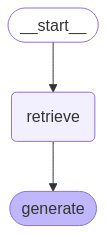

In [356]:
graph

Let's take it for a spin!

We invoke our graph like we do any other Runnable in LCEL!

> NOTE: That's right, even a compiled graph is a Runnable!

In [357]:
response = graph.invoke({"question" : "How does LCEL work?"})
display_markdown(response["response"])

LCEL, or LangChain Expression Language, is a declarative way to compose chains together. It offers several benefits, including:

1. **Async, Batch, and Streaming Support**: Chains constructed using LCEL automatically support synchronous, asynchronous, batch, and streaming operations, making it easy to prototype in a Jupyter notebook and then expose it as an async streaming interface.

2. **Fallbacks**: Given the non-determinism of large language models (LLMs), LCEL allows for graceful error handling by easily attaching fallbacks to any chain.

3. **Parallelism**: LCEL syntax facilitates running components in parallel, which is important for LLM applications that may involve lengthy API calls. Any components that can run in parallel will do so automatically.

These features make LCEL a powerful tool for building chains in a flexible and efficient manner.

In [358]:
response = graph.invoke({"question" : "Who is Batman?"})

display_markdown(response["response"])

I don't know.

#### ❓ Question #4:
LangGraph's graph-based approach lets us visualize and manage complex flows naturally. How could we extend our current implementation to handle edge cases? For example:
(A) What if the retriever finds no relevant context?  
(B) What if the response needs fact-checking?
Consider how you would modify the graph to handle these scenarios.


#### ❗ Answer #4:

For the question (B) I guess there could be another context database of "facts".
The answer to the query could be piped to the model with a different query
(and potentially temperature) that would validate the model against the facts.
I imagine this may be conceptually similar to the case when we request the output
in a particular format, e.g., JSON schema, which can then be validated against
a schema validator. 

(A) If the retriever finds no relevant context, we can use the fallback
mechanism for LCEL to "unmoor" the LLM from RAG and see if we can 
freestyle an answer.



First, we implement a validator that checks if the first LLM had a valid answer.

In [359]:
from langchain_core.runnables import RunnableLambda
from langchain_core.exceptions import OutputParserException

def validate_output(output: str) -> str:
    if "I don't know" in output:
        raise OutputParserException("Unacceptable answer")
    return output

validator = RunnableLambda(validate_output)


Then we create a second version of the prompt that doesn't use the context
but rather issues a warning about context being ignored.

In [360]:

HUMAN_CONTEXT_FREE_TEMPLATE = """
QUERY:
{query}

Before answering the query, issue a warning that the context has been disabled
in order to provide an answer not present in the context. Use all caps for this
part of your answer."""

chat_prompt_unmoored = ChatPromptTemplate.from_messages([
    ("human", HUMAN_CONTEXT_FREE_TEMPLATE)
])



Finally, we create a new generator, which has the main chain as before,
with the addition of the response generator.

The new prompt is used to create the fallback chain (which doesn't need a 
validator since we don't have a second fallback option).

In [365]:

def generate_resilient(state: State) -> State:
  fallback_chain = chat_prompt_unmoored | openai_chat_model  | StrOutputParser()  
  generation_chain = (
      chat_prompt | openai_chat_model | StrOutputParser() | validator 
  )
  resilient_chain = generation_chain.with_fallbacks([fallback_chain])
  
  response = resilient_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}



In [361]:
graph_resilient_builder = StateGraph(State)
graph_resilient_builder = graph_resilient_builder.add_sequence([retrieve, generate_resilient])
graph_resilient_builder.add_edge(START, "retrieve")
graph_resilient = graph_resilient_builder.compile()


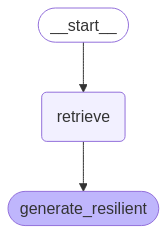

In [362]:
graph_resilient


Now, let's see that the question about LCEL is still answered from context.

In [363]:
display_markdown(graph_resilient.invoke({"question" : "What is LCEL?"})["response"])

LCEL, or LangChain Expression Language, is a declarative way to easily compose chains together. It offers several benefits, such as automatic support for synchronous, asynchronous, batch, and streaming operations, allowing for easy prototyping in environments like Jupyter notebooks. Additionally, LCEL provides features like fallbacks to handle errors gracefully due to the non-determinism of LLMs, and it allows for parallel execution of components, which is important for managing sometimes lengthy API calls in LLM applications.

And the question of Batman has a more substantive response, but with a warning.

In [364]:
display_markdown(graph_resilient.invoke({"question" : "What is Batman?"})["response"])

WARNING: THE CONTEXT HAS BEEN DISABLED. 

Batman is a fictional superhero created by artist Bob Kane and writer Bill Finger, appearing primarily in comic books published by DC Comics. He made his first appearance in "Detective Comics" #27 in 1939. Batman, whose real identity is Bruce Wayne, is a wealthy industrialist and philanthropist who fights crime in Gotham City using his intelligence, physical prowess, and an array of high-tech gadgets. Unlike many superheroes, Batman does not possess superhuman powers; instead, he relies on his skills in hand-to-hand combat, detective work, and strategic planning. He is often aided by allies such as Robin, Batgirl, and Alfred Pennyworth, and he is known for his strong moral code, particularly against using lethal force.